In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# 1. Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')


In [3]:
df.head()

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [5]:
# 2. Setup Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [6]:
# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 3. Initialize AdaBoost Regressor
# We use a base Decision Tree with a depth of 4 to capture non-linearities
base_model = DecisionTreeRegressor(max_depth=4)
ada_model = AdaBoostRegressor(estimator=base_model, n_estimators=100, learning_rate=0.1, random_state=42)

In [8]:
# 4. Train the model
ada_model.fit(X_train, y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                  learning_rate=0.1, n_estimators=100, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

# Initialize and train a Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression Model Trained.")

Linear Regression Model Trained.


In [14]:
# Predict and Evaluate Linear Regression
y_pred_linear = linear_model.predict(X_test)

r2_linear = r2_score(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print(f"--- Linear Regression Model Evaluation ---")
print(f"R2 Score (Linear Regression): {r2_linear:.4f}")
print(f"MAE (Linear Regression): {mae_linear:.2f} MPa")
print(f"RMSE (Linear Regression): {rmse_linear:.2f} MPa")

--- Linear Regression Model Evaluation ---
R2 Score (Linear Regression): 0.9525
MAE (Linear Regression): 25.20 MPa
RMSE (Linear Regression): 31.51 MPa


In [15]:
# Compare AdaBoost vs. Linear Regression

comparison_data = {
    'Model': ['AdaBoost Regressor', 'Linear Regression'],
    'R2 Score': [r2_score(y_test, y_pred), r2_linear],
    'MAE (MPa)': [mean_absolute_error(y_test, y_pred), mae_linear],
    'RMSE (MPa)': [np.sqrt(mean_squared_error(y_test, y_pred)), rmse_linear]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))

,Model,R2 Score,MAE (MPa),RMSE (MPa)
0,AdaBoost Regressor,0.9318,30.3638,37.7543
1,Linear Regression,0.9525,25.2017,31.5112


In [11]:
# 5. Predict and Evaluate
y_pred = ada_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} MPa")
print(f"RMSE: {rmse:.2f} MPa")

R2 Score: 0.9318
MAE: 30.36 MPa
RMSE: 37.75 MPa


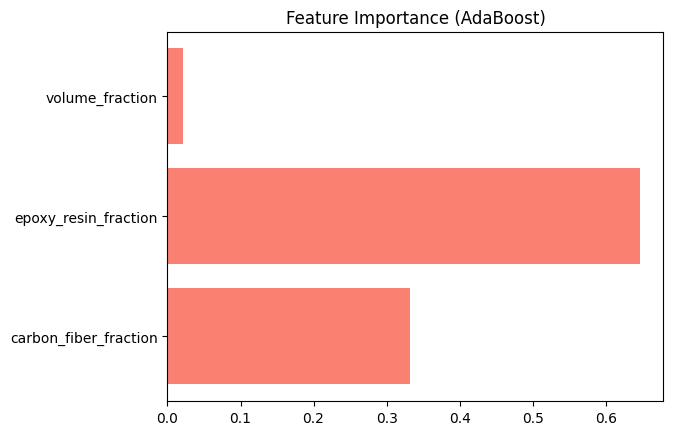

In [12]:
# 6. Feature Importance Visualization
plt.barh(X.columns, ada_model.feature_importances_, color='salmon')
plt.title("Feature Importance (AdaBoost)")
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for AdaBoost
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5],
    'estimator__max_depth': [2, 4, 6] # max_depth for the base DecisionTreeRegressor
}

# Initialize the base model
base_model_tune = DecisionTreeRegressor(random_state=42)

# Initialize AdaBoost Regressor with the base model
ada_model_tune = AdaBoostRegressor(estimator=base_model_tune, random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=ada_model_tune, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best RMSE found: ", np.sqrt(-grid_search.best_score_))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found:  {'estimator__max_depth': 4, 'learning_rate': 0.5, 'n_estimators': 200}
Best RMSE found:  31.429505126734014


Now, let's train a new AdaBoost model using these best parameters and evaluate its performance on the test set.

In [17]:
# Train a new AdaBoost model with the best parameters
best_ada_model = grid_search.best_estimator_
best_ada_model.fit(X_train, y_train)

# Make predictions on the test set with the best model
y_pred_tuned = best_ada_model.predict(X_test)

# Evaluate the tuned AdaBoost model
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"--- Tuned AdaBoost Model Evaluation ---")
print(f"R2 Score (Tuned AdaBoost): {r2_tuned:.4f}")
print(f"MAE (Tuned AdaBoost): {mae_tuned:.2f} MPa")
print(f"RMSE (Tuned AdaBoost): {rmse_tuned:.2f} MPa")

--- Tuned AdaBoost Model Evaluation ---
R2 Score (Tuned AdaBoost): 0.9335
MAE (Tuned AdaBoost): 29.12 MPa
RMSE (Tuned AdaBoost): 37.28 MPa


Let's compare the performance of the original AdaBoost, Linear Regression, and the hyperparameter-tuned AdaBoost model.

In [18]:
# Compare all models

comparison_data_tuned = {
    'Model': ['AdaBoost Regressor (Original)', 'Linear Regression', 'AdaBoost Regressor (Tuned)'],
    'R2 Score': [r2_score(y_test, y_pred), r2_linear, r2_tuned],
    'MAE (MPa)': [mean_absolute_error(y_test, y_pred), mae_linear, mae_tuned],
    'RMSE (MPa)': [np.sqrt(mean_squared_error(y_test, y_pred)), rmse_linear, rmse_tuned]
}

comparison_df_tuned = pd.DataFrame(comparison_data_tuned)
display(comparison_df_tuned.round(4))

,Model,R2 Score,MAE (MPa),RMSE (MPa)
0,AdaBoost Regressor (Original),0.9318,30.3638,37.7543
1,Linear Regression,0.9525,25.2017,31.5112
2,AdaBoost Regressor (Tuned),0.9335,29.1244,37.2821
